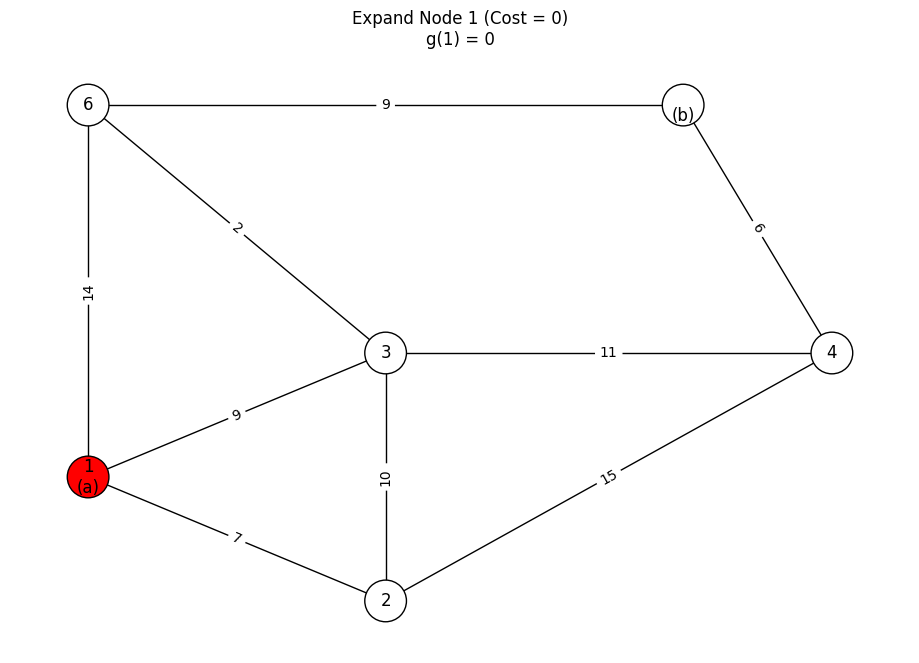

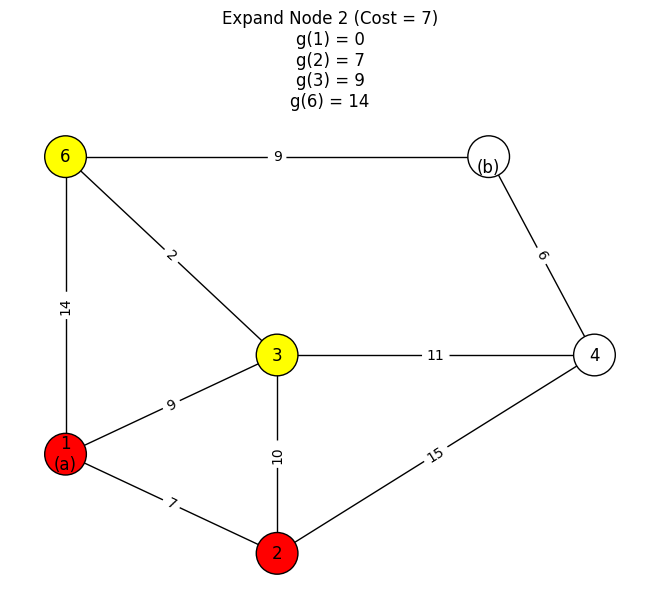

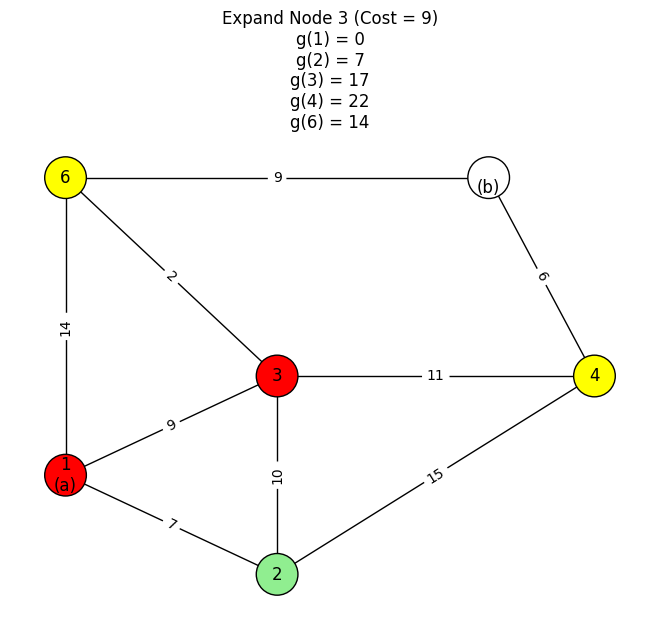

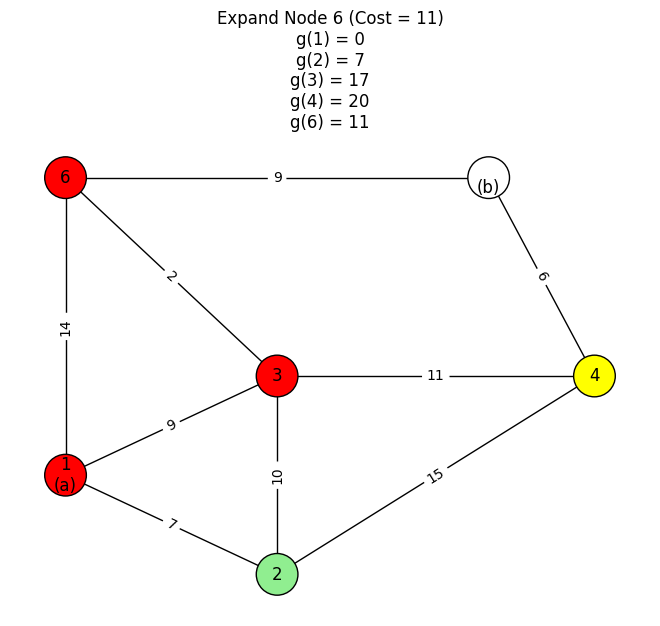

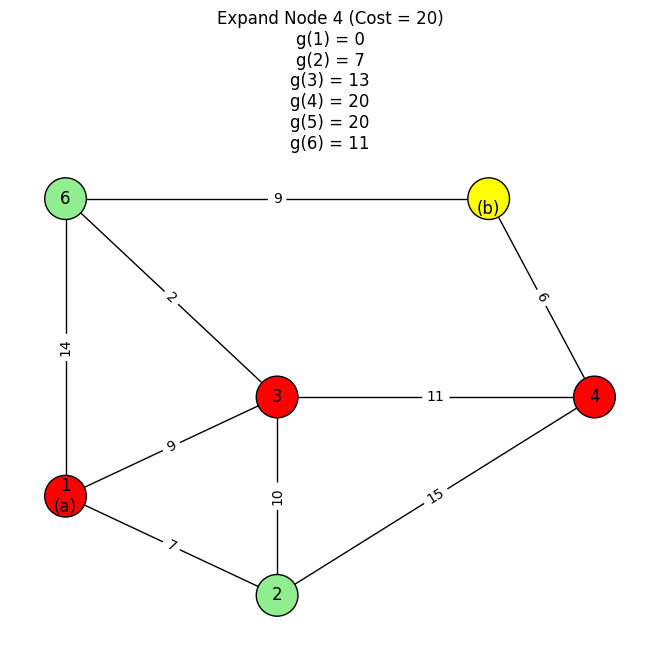

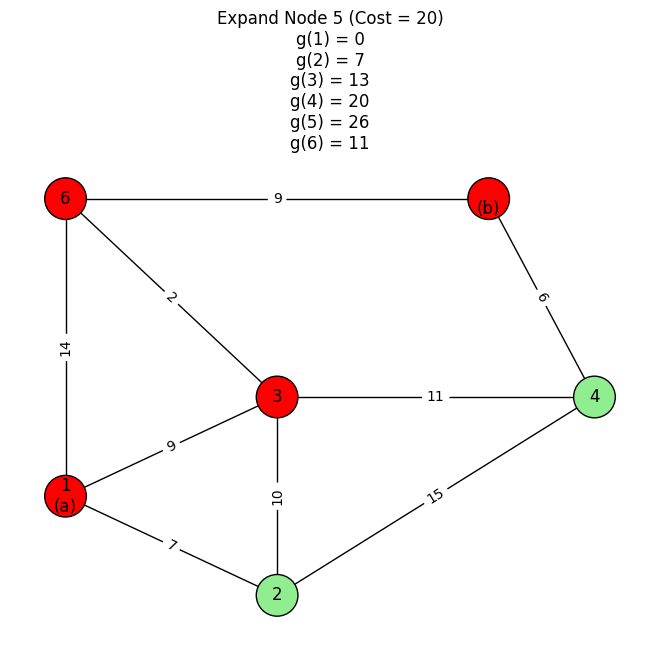

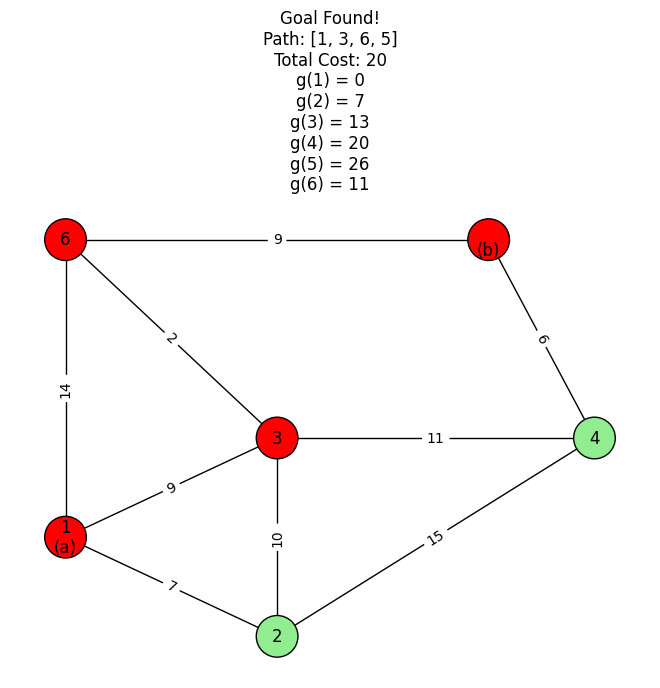

In [2]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    1: [(2,7), (3,9), (6,14)],
    2: [(1,7), (3,10), (4,15)],
    3: [(1,9), (2,10), (4,11), (6,2)],
    4: [(2,15), (3,11), (5,6)],
    5: [(4,6), (6,9)],
    6: [(1,14), (3,2), (5,9)]
}
pos = {
    1: (0,0),
    2: (2,-1),
    3: (2,1),
    4: (5,1),
    5: (4,3),
    6: (0,3)
}
labels = {
    1:"1\n(a)",
    2:"2",
    3:"3",
    4:"4",
    5:"\n(b)",
    6:"6"
}
G = nx.Graph()
for u in graph:
  for v,w in graph[u]:
    if not G.has_edge(u,v):
      G.add_edge(u,v,weight=w)

# Define the draw function
def draw(current, finalized_nodes, frontier_nodes, path, min_costs_to_node, title):
  plt.clf()
  colors = []
  for node in G.nodes():
    if node in path:
      colors.append("red")
    elif node == current:
      colors.append("deepskyblue")
    elif node in finalized_nodes:
      colors.append("lightgreen")
    elif node in frontier_nodes:
      colors.append("yellow")
    else:
      colors.append("white")

  nx.draw(
      G,
      pos,
      with_labels=False,
      node_color=colors,
      node_size=900,
      edgecolors="black"
  )
  nx.draw_networkx_labels(G,pos,labels)
  nx.draw_networkx_edge_labels(
      G,
      pos,
      edge_labels=nx.get_edge_attributes(G,"weight")
  )
  # Format costs for display
  costs_text = "\n".join(
      [
          f"g({k}) = {v}"
          for k,v in sorted(min_costs_to_node.items())
      ]
  )
  plt.title(title + "\n" + costs_text) # Combine title and costs info
  plt.pause(2)

# Main algorithm logic (Dijkstra/A* with visualization)
pq = [(0, 1, [1])] # (cost, node, path)
min_costs_to_node = {1:0} # Stores the current best known cost to reach a node (like 'dist' in Dijkstra)
finalized_nodes = {} # Stores the final minimum cost found for a node (like 'visited' set but stores cost)
final = []

plt.figure(figsize=(9,6))

while pq:
  # Current nodes in the priority queue (frontier)
  # Create a set from nodes in pq for quick lookup in draw function
  current_frontier = {node for _, node, _ in pq}

  cost, node, path = heapq.heappop(pq)

  # If this node has already been finalized with a shorter or equal path, skip
  if node in finalized_nodes and cost >= finalized_nodes[node]:
    continue

  finalized_nodes[node] = cost # Finalize this node's cost

  draw(
      node, # current node being expanded
      finalized_nodes, # These are nodes whose shortest path is confirmed
      current_frontier, # These are nodes currently awaiting expansion in PQ
      path, # path to the current node
      min_costs_to_node, # All costs known so far
      f"Expand Node {node} (Cost = {cost})"
  )

  if node == 5: # Assuming 5 is the target node
    final = path
    break

  for neighbor, weight in graph[node]:
    newCost = cost + weight
    # If the neighbor has not been finalized OR a shorter path is found
    if neighbor not in finalized_nodes or newCost < min_costs_to_node.get(neighbor, float('inf')):
      min_costs_to_node[neighbor] = newCost # Update the current best known cost
      heapq.heappush(
          pq,
          (
              newCost,
              neighbor,
              path + [neighbor]
          )
      )

# After the loop, if a path was found, draw the final state
if final:
  draw(
      None, # No 'current' node to highlight as search is complete
      finalized_nodes,
      set(), # Frontier is empty
      final, # The final path
      min_costs_to_node,
      f"Goal Found!\nPath: {final}\nTotal Cost: {finalized_nodes.get(5, 'N/A')}"
  )
plt.show()